# Study of the Enigh database

In this work we approach the database Enigh 2018. Enigh is *the National Survey of Household Income and Expenditure*, it take place in Mexico, has as objectives:
- To provide a statistical overview of household income and expenditure patterns in terms of amount, source, and distribution.

- To provide information on the occupational and sociodemographic characteristics of household members, and

- Present data on the characteristics of the housing infrastructure and household equipment.

The main purpose of this study is to classify the socioeconomic stratum according to household expenditures, household size, household type, etc.

## Data loading

We begin by loading the dataset, wich can be obtained from the INEGI website

In [1]:
#The necessary packages for the project
import pandas as pd
import numpy as np
import os
from plotnine import *
import matplotlib.pyplot as plt
import seaborn as sns
enigh = pd.read_csv(r'C:\Users\aleja\OneDrive\Documentos\Curso R studio\hogares_enigh.csv')

In [2]:
enigh.shape


(74647, 26)

Categorical labels were translated into English for presentation purposes, while variable definitions follow the original ENIGH classification.



In [3]:
enigh.replace({'clase_hog':{
    1: "Single-person",
    2: "Nuclear",
    3: "Extended",
    4: "Composite",
    5: "Correspondent"
}}, inplace=True)

enigh.replace({"sexo_jefe":{
    1: "Male",
    2: "Female"
}}, inplace=True)

enigh.replace({"educa_jefe":{
    1: "No schooling",
    2: "Preschool",
    3: "Incomplete primary",
    4: "Complete primary",
    5: "Incomplete secondary",
    6: "Complete secondary",
    7: "Incomplete high school",
    8: "Complete high school",
    9: "Incomplete professional",
    10: "Complete professional",
    11: "Postgraduate"
}}, inplace=True)

enigh.replace({"est_socio":{
    1:"Low",
    2:"Lower-middle",
    3:"Upper-middle",
    4:"High"
}}, inplace=True)

In [4]:
#It was decided to remove scientific notation
pd.options.display.float_format="{:,.2f}".format

In [5]:
enigh.head()

,folioviv,foliohog,ubica_geo,tam_loc,est_socio,est_dis,upm,factor,clase_hog,sexo_jefe,...,gasto_mon,alimentos,vesti_calz,vivienda,limpieza,salud,transporte,educa_espa,personales,transf_gas
0,100013601,1,1001,1,Upper-middle,2,1,175,Nuclear,Male,...,"18,551.47","5,618.47",0.00,"3,912.00",522.00,0.00,"8,400.00",0.00,99.00,0.00
1,100013602,1,1001,1,Upper-middle,2,1,175,Nuclear,Male,...,"55,470.99","20,930.29",401.06,"2,495.00",412.16,"1,348.99","7,628.56","17,567.05","4,663.29",24.59
2,100013603,1,1001,1,Upper-middle,2,1,175,Nuclear,Male,...,"103,106.89","37,594.06","2,015.21","4,475.00","3,318.26","28,858.68","12,325.68",0.00,"8,520.00","6,000.00"
3,100013604,1,1001,1,Upper-middle,2,1,175,Nuclear,Female,...,"19,340.06","2,892.84",97.82,"1,458.00","5,514.00",322.82,"7,350.00",639.34,"1,065.24",0.00
4,100013606,1,1001,1,Upper-middle,2,1,175,Nuclear,Female,...,"13,605.03","7,367.09",0.00,300.00,"3,300.00",56.73,600.00,0.00,"1,686.13",295.08


### Exploratory data analysis (EDA)


An important variable for this study is the current income, which in the Enigh database is known as ing_cor. Current income is the money that a person or household receives regularly in a given period (month, quarter, year), and which is mainly used for everyday expenses.


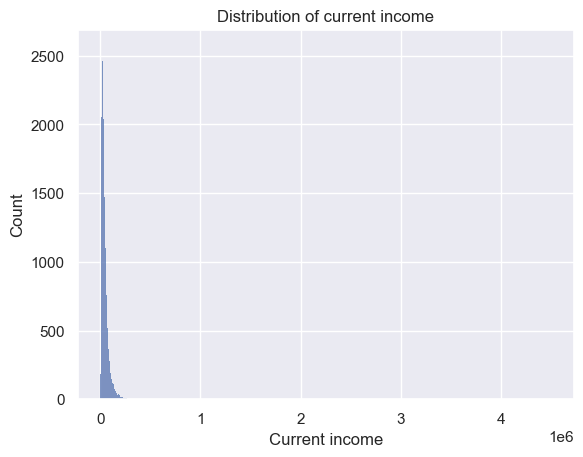

In [6]:
sns.set_theme()
sns.histplot(data=enigh,x="ing_cor")
plt.xlabel("Current income")
plt.ylabel("Count")
plt.title("Distribution of current income")
plt.show()

In many cases, it's common to find outliers. These outliers ruin the analysis because they skew the mean too much. One possible solution is to remove them or apply transformations to the data. In this case we select the current income less than $200,000.

The following graph shows the distribution of the number of members per household. We can observe that most households have 3 and 4 members, which represents a trend opposite to the large families of previous generations. 

Other way as follows is count the households with a certain number of members.

In [7]:
enigh2=enigh[enigh["ing_cor"]<200000]
enigh2.shape

(73718, 26)

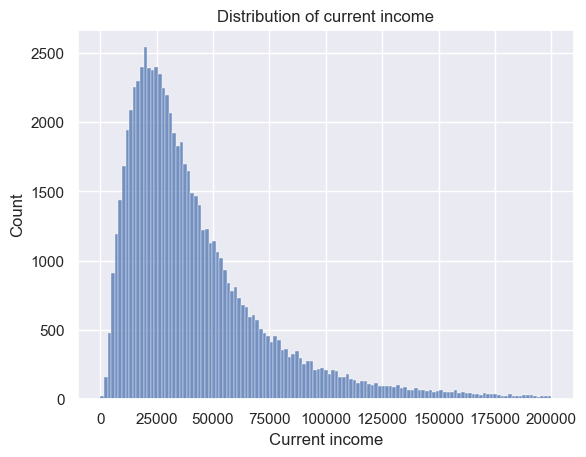

In [8]:
sns.histplot(data=enigh2,x="ing_cor")
plt.xlabel("Current income")
plt.ylabel("Count")
plt.title("Distribution of current income")
plt.show()

Given that It is in our interest focus on the social stratum, in the following frecuency polygon, we show the current income per social stratum. The income distribution is right-skewed, indicating an inequality problem.


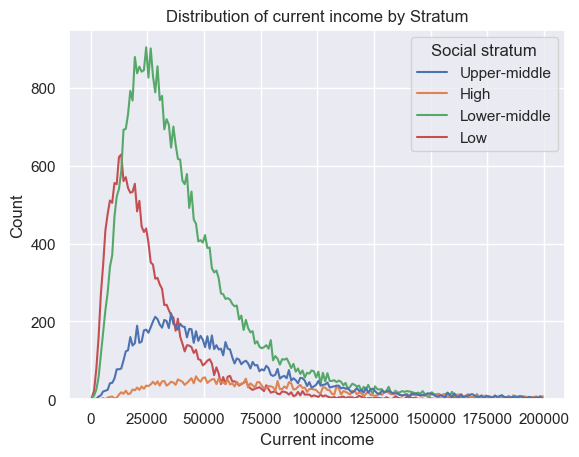

In [9]:
ax = sns.histplot(
    data=enigh2,
    x="ing_cor",
    hue="est_socio",
    binwidth=1000,
    fill=False,
    element="poly",
    stat="count",
    common_norm=False
)

# En lugar de plt.legend(), usamos esto para cambiar el título sin romper los colores
sns.move_legend(ax, "upper right", title="Social stratum")

plt.xlabel("Current income")
plt.ylabel("Count")
plt.title("Distribution of current income by Stratum")

plt.show()

In [10]:
household_class=(enigh.groupby('est_socio').size().reset_index(name="#"))
household_class.head(20)

,est_socio,#
0,High,4782
1,Low,17979
2,Lower-middle,39285
3,Upper-middle,12601


It is also of our interest to show the relationship between social stratum and certain expenditures, such as food expenditure, health expenditure and education expenditure. Health and food expenditures were selected as the primary variables for exploratory analysis because they represent the most fundamental household needs. These two categories reflect basic survival and well-being, making them essential indicators of a household's economic capacity. Additionally, education expenditure was included due to its role as a key differentiator across socioeconomic strata — households in higher strata tend to allocate significantly more resources to education, making it a strong discriminating variable for classification purposes

In [11]:
enigh.shape

(74647, 26)

Tamaño original: (74647, 26)
Tamaño filtrado: (29285, 26)


Text(0.5, 1.0, 'Distribution of expenditure in health by social stratum')

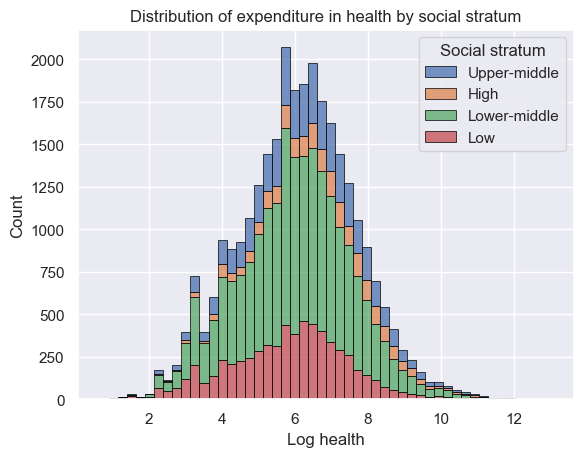

In [12]:
enigh3 = enigh[
    (enigh["salud"] > 0) &
    (enigh["alimentos"] > 0) &
    (enigh["educa_espa"] > 0)&
    (enigh["ing_cor"])>0
].copy()

print("Tamaño original:", enigh.shape)
print("Tamaño filtrado:", enigh3.shape)



enigh3['ln_salud'] = np.log(enigh3['salud'])
enigh3['ln_educacion'] = np.log(enigh3['educa_espa'])
enigh3['ln_alimentos'] = np.log(enigh3['alimentos'])
enigh3['ln_ing_cor'] = np.log(enigh3['ing_cor'])


ax=sns.histplot(
    data=enigh3, 
    x='ln_salud', 
    hue='est_socio', 
    element="bars", 
    bins=50, 
    multiple="stack",     
    edgecolor='black',    
    linewidth=0.5,
)
sns.move_legend( ax,loc="upper right", title="Social stratum")

plt.xlabel("Log health")
plt.title("Distribution of expenditure in health by social stratum")

For health expenditures, we can identify that strata low and lower-middle are grouped slightly more to the right, which indicates a positive skewness, meaning they can allocate a higher expenditure on health. It would not be surprising if all strata show a similar central tendency and a normal distribution.

Text(0.5, 1.0, 'Distribution of expenditure in food by social stratum')

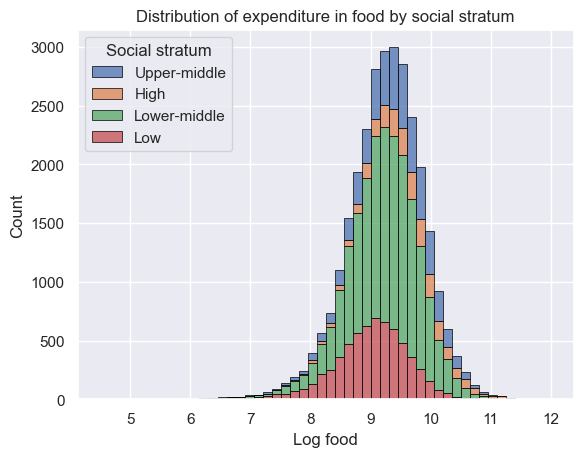

In [13]:

ax=sns.histplot(
    data=enigh3, 
    x='ln_alimentos', 
    hue='est_socio', 
    element="bars", 
    bins=50, 
    multiple="stack",     
    edgecolor='black',    
    linewidth=0.5,
)
sns.move_legend( ax,loc="upper left", title="Social stratum")

plt.xlabel("Log food")
plt.title("Distribution of expenditure in food by social stratum")

Text(0.5, 1.0, 'Distribution of expenditure in food by social stratum')

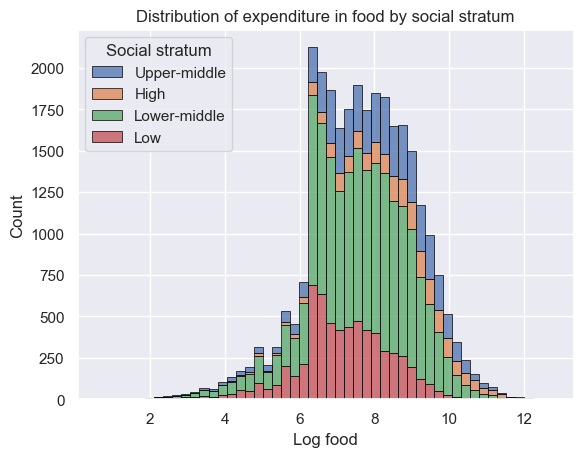

In [14]:


ax=sns.histplot(
    data=enigh3, 
    x='ln_educacion', 
    hue='est_socio', 
    element="bars", 
    bins=50, 
    multiple="stack",     
    edgecolor='black',    
    linewidth=0.5,
)
sns.move_legend( ax,loc="upper left", title="Social stratum")

plt.xlabel("Log food")
plt.title("Distribution of expenditure in food by social stratum")

Based on the provided data, we can perform the following analysis of the variables  expenditures in ‘health’, ‘food’, and ‘Education’.

When observing the minimum, maximum, and quartile values of the three variables, we can notice a wide dispersion in the data. For example, in the ‘health’ variable, the values range from 1.95 to 455,869.55, which suggests that there are observations with significant differences in health expenditures. The same applies to the other two variables.

The median (represented by ‘50 %’) provides a measure of central tendency located at the midpoint of the data. For instance, in the ‘food’ variable, the median is approximately 10,682.74, meaning that half of the observations are above this value and the other half below.

By comparing the means  with the medians, we can get an idea of whether the distributions are symmetric or skewed. For example, in the ‘health’ variable, the mean is approximately 1,614.42, while the median is 449.97. This difference indicates that the distribution is skewed to the right, since the mean is higher than the median, as we also observed in the histogram.

Looking at the maximum values, we can note the presence of possible outliers or extremely high values. For example, in the ‘education expenditure’ variable, the maximum value is 337,619.57, which is considerably higher than the third quartile

In [15]:
summ=enigh[["alimentos","salud","educa_espa"]].describe()

summ.columns = [
    "Food Expenditure",
    "Health Expenditure",
    "Education Expenditure"
]
summ

,Food Expenditure,Health Expenditure,Education Expenditure
count,"74,647.00","74,647.00","74,647.00"
mean,"10,395.56",797.76,"3,228.98"
std,"7,563.25","4,680.81","7,868.98"
min,0.00,0.00,0.00
25%,"5,451.33",0.00,0.00
50%,"8,777.45",23.47,782.60
75%,"13,352.01",449.98,"3,270.02"
max,"231,415.46","455,869.55","337,619.57"


## Boxplot
A boxplot displays the spread and skewness of data, highlighting the median, quartiles, and possible outliers.  Other importan variable is the percapita income, we show it by the differents social strata. The lower stratum shows a skewed distribution in per capita income, with a median consistent with its socioeconomic classification, although there are outliers that could reflect a disconnect between the household’s current income and the assigned stratum.

C:\Users\aleja\AppData\Local\Temp\ipykernel_18752\281123256.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


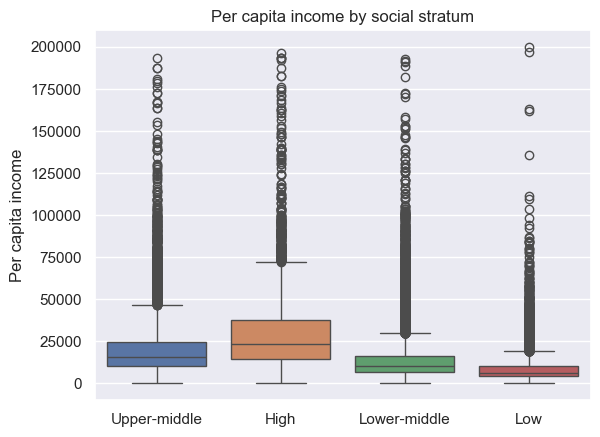

In [16]:
enigh2["per_capita"]=enigh2["ing_cor"]/enigh2["tot_integ"]

sns.boxplot(data=enigh2,x="est_socio",y="per_capita",hue="est_socio")
plt.ylabel("Per capita income")
plt.xlabel("")
plt.title("Per capita income by social stratum")
plt.show()

In addition to focusing on the social stratum, we will also analyze the variables that will allow us to carry out our classification, such as per capita income, household type, the educational level of the head of household, etc.

## Heatmap
In the following heatmap, we observe that the lower and middle classes tend to have a low level of education, in contrast to the upper classes, where we observe a higher level of education.

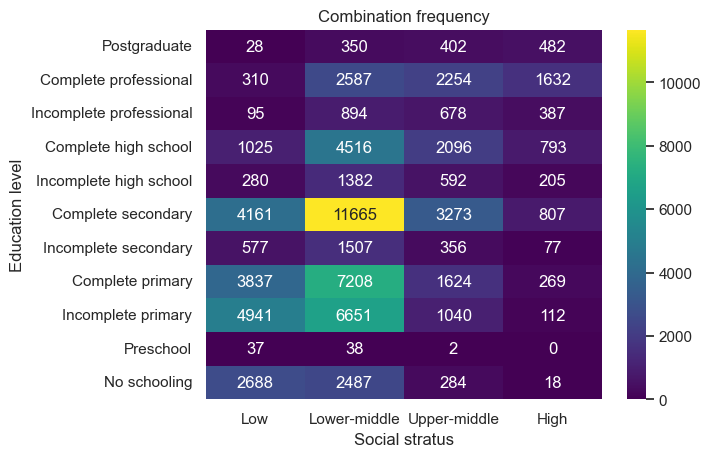

In [17]:
order = [
    "Postgraduate",
    "Complete professional",
    "Incomplete professional",
    "Complete high school",
    "Incomplete high school",
    "Complete secondary",
    "Incomplete secondary",
    "Complete primary",
    "Incomplete primary",
    "Preschool",
    "No schooling"
]


tabla_freq = pd.crosstab(enigh['educa_jefe'], enigh['est_socio'])
tabla_freq = tabla_freq.reindex(order)
tabla_freq = tabla_freq.reindex(columns=["Low","Lower-middle","Upper-middle","High"])

sns.heatmap(
    tabla_freq,
    annot=True,      # Mostrar números
    fmt='d',         # Formato entero
    cmap='viridis')

plt.xlabel("Social stratus")
plt.ylabel("Education level")
plt.title('Combination frequency')
plt.show()

## Correlation plots


One way to verify the quality of our data is by checking whether certain obvious assumptions are met. For example, in the following scatter plot we observe something that can be expected: single-person households spend less on food.

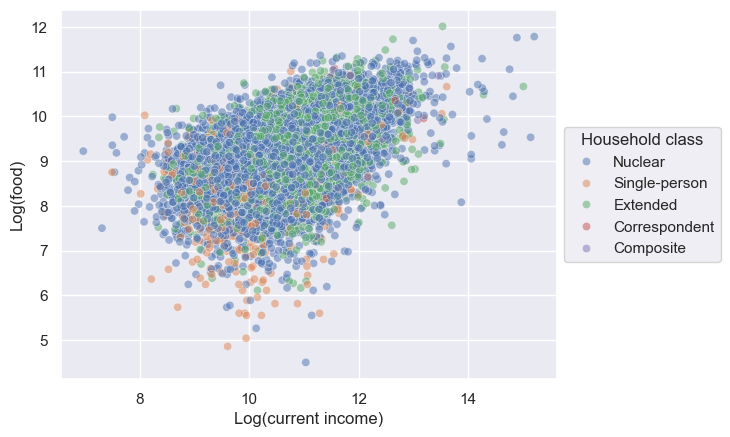

In [18]:

sns.scatterplot(data=enigh3,
               x="ln_ing_cor",
               y="ln_alimentos",
               hue="clase_hog",
               alpha=0.5   # Añadimos transparencia para ver donde hay más densidad de puntos
               )
plt.xlabel("Log(current income)")
plt.ylabel("Log(food)")
plt.legend(title="Household class",loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

In the following scatter plot, we can notice that there is a linear relationship between current expenditure and spending on education. We can see that the groups with higher income spend more on education and therefore achieve a higher level of education. On the other hand, the groups with lower levels of education spend less on education. It is also observed that current income is lower among those groups with less education, which in some way breaks the Mexican myth of the wealthy taco vendor.

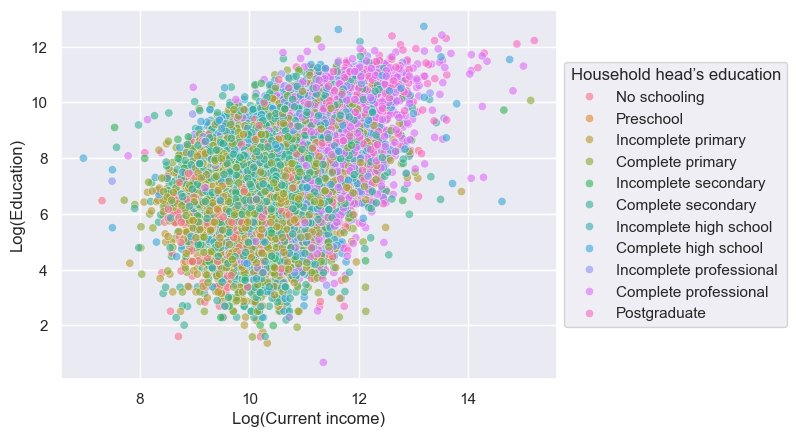

In [19]:
order=[
     "No schooling",
     "Preschool",
     "Incomplete primary",
     "Complete primary",
     "Incomplete secondary",
     "Complete secondary",
     "Incomplete high school",
     "Complete high school",
     "Incomplete professional",
     "Complete professional",
     "Postgraduate"
]


sns.scatterplot(data=enigh3,
               x="ln_ing_cor",
               y="ln_educacion",
               hue="educa_jefe",
               hue_order=order,
               alpha=0.6)

plt.xlabel("Log(Current income)")
plt.ylabel("Log(Education)")

plt.legend(title="Household head’s education",loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()


## Classification of  social strata

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [21]:
# Use LabelEncoder to process alphanumeric variables

enigh["per_capita"]=enigh["ing_cor"]/enigh["tot_integ"]



def label_encoder(datos_categoria):
    le = LabelEncoder()
    enigh[datos_categoria] = le.fit_transform(enigh[datos_categoria])

variables = ["est_socio", "clase_hog", "sexo_jefe", "educa_jefe"]
for i in variables:
    label_encoder(i)

y = enigh["est_socio"]

x = enigh[["clase_hog", "sexo_jefe", "edad_jefe", "tot_integ", "ing_cor", 
           "alimentos", "salud", "educa_espa", "educa_jefe", "vivienda", 
           "limpieza", "transporte", "personales", "transf_gas", "vesti_calz","per_capita","gasto_mon"]]

In [22]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

              precision    recall  f1-score   support

           0       0.45      0.18      0.26       957
           1       0.70      0.41      0.52      3596
           2       0.59      0.89      0.71      7857
           3       0.43      0.09      0.15      2520

    accuracy                           0.60     14930
   macro avg       0.54      0.39      0.41     14930
weighted avg       0.58      0.60      0.54     14930



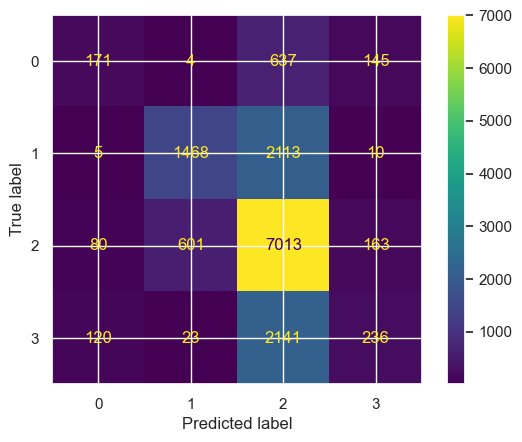

In [23]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
# 2. Entrenar modelo
rf = RandomForestClassifier(n_estimators=400, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# 3. Predecir
y_pred = rf.predict(X_test)

# 4. Evaluar
print(classification_report(y_test, y_pred))

# 5. Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [24]:
enigh.shape

(74647, 27)

An initial model was trained using only income and expenditure variables from the ENIGH concentrated dataset, achieving an accuracy of 57%. To improve the model's predictive capacity, housing characteristics from the ENIGH viviendas table were incorporated, given that the socioeconomic stratum was originally constructed using physical housing and socioeconomic indicators.

In [25]:
viviendas=pd.read_csv("viviendas.csv",low_memory=False)

In [26]:
viviendas.head()

,folioviv,tipo_viv,mat_pared,mat_techos,mat_pisos,antiguedad,antigua_ne,cocina,cocina_dor,cuart_dorm,...,tot_hom,tot_muj,tot_hog,ubica_geo,tam_loc,est_socio,est_dis,upm,factor,procaptar
0,100013601,1,8,10,3,42,,1,2,4,...,2,1,1,1001,1,3,2,1,179,0
1,100013602,1,8,10,3,40,,1,2,5,...,2,3,1,1001,1,3,2,1,179,0
2,100013603,1,8,10,3,50,,1,2,2,...,1,1,1,1001,1,3,2,1,179,0
3,100013604,1,8,10,3,45,,1,2,2,...,1,1,1,1001,1,3,2,1,179,0
4,100013606,1,8,10,3,40,,1,2,3,...,1,3,1,1001,1,3,2,1,179,0


In [27]:
for col in viviendas.columns:
    if (viviendas[col] == '&').any():
        print(col, (viviendas[col] == '&').sum())

tipo_viv 51
mat_pisos 4
combustible 1
tipo_finan 463


In [28]:
viviendas['tipo_viv'] = viviendas['tipo_viv'].replace('&', np.nan)
viviendas['mat_pisos'] = viviendas['mat_pisos'].replace('&', np.nan)
viviendas['tipo_viv'] = viviendas['tipo_viv'].fillna(viviendas['tipo_viv'].mode()[0])
viviendas['mat_pisos'] = viviendas['mat_pisos'].fillna(viviendas['mat_pisos'].mode()[0])

In [29]:
pared_map = {
    1: "Waste material",
    2: "Cardboard sheet",
    3: "Asbestos or metal sheet",
    4: "Reed bamboo or palm",
    5: "Mud or wattle",
    6: "Wood",
    7: "Adobe",
    8: "Brick, block or stone"
}
viviendas['mat_pared'] = viviendas['mat_pared'].replace(pared_map)
tipo_map = {
    "1": "Independent house",
    "2": "Apartment in building",
    "3": "Tenement housing",
    "4": "Rooftop room",
    "5": "Non-residential space"
}
viviendas['tipo_viv'] = viviendas['tipo_viv'].replace(tipo_map)

techo_map = {
    1: "Waste material",
    2: "Cardboard sheet",
    3: "Metal sheet",
    4: "Asbestos sheet",
    5: "Corrugated fiber cement sheet",
    6: "Palm or straw",
    7: "Wood or shingle",
    8: "Earthen roof with beams",
    9: "Clay tile",
    10: "Concrete slab"
}

viviendas['mat_techos'] = viviendas['mat_techos'].replace(techo_map)

piso_map = {
    "1": "Dirt",
    "2": "Cement",
    "3": "Wood, mosaic or other covering"
}

viviendas['mat_pisos'] = viviendas['mat_pisos'].replace(piso_map)



In [44]:
viviendas.head()

,folioviv,tipo_viv,mat_pared,mat_techos,mat_pisos,antiguedad,antigua_ne,cocina,cocina_dor,cuart_dorm,...,tot_hom,tot_muj,tot_hog,ubica_geo,tam_loc,est_socio,est_dis,upm,factor,procaptar
0,100013601,Independent house,"Brick, block or stone",Concrete slab,"Wood, mosaic or other covering",42,,1,2,4,...,2,1,1,1001,1,3,2,1,179,0
1,100013602,Independent house,"Brick, block or stone",Concrete slab,"Wood, mosaic or other covering",40,,1,2,5,...,2,3,1,1001,1,3,2,1,179,0
2,100013603,Independent house,"Brick, block or stone",Concrete slab,"Wood, mosaic or other covering",50,,1,2,2,...,1,1,1,1001,1,3,2,1,179,0
3,100013604,Independent house,"Brick, block or stone",Concrete slab,"Wood, mosaic or other covering",45,,1,2,2,...,1,1,1,1001,1,3,2,1,179,0
4,100013606,Independent house,"Brick, block or stone",Concrete slab,"Wood, mosaic or other covering",40,,1,2,3,...,1,3,1,1001,1,3,2,1,179,0


In [31]:
cols_vivienda = ['folioviv', 'tipo_viv', 'mat_pared', 'mat_techos', 'mat_pisos', 'num_cuarto']
viviendas_clean = viviendas[cols_vivienda]

# 2. Merge con enigh
enigh = enigh.merge(viviendas_clean, on='folioviv', how='left')

              precision    recall  f1-score   support

           0       0.49      0.19      0.28       957
           1       0.72      0.42      0.53      3596
           2       0.61      0.88      0.72      7857
           3       0.49      0.19      0.28      2520

    accuracy                           0.61     14930
   macro avg       0.58      0.42      0.45     14930
weighted avg       0.61      0.61      0.57     14930



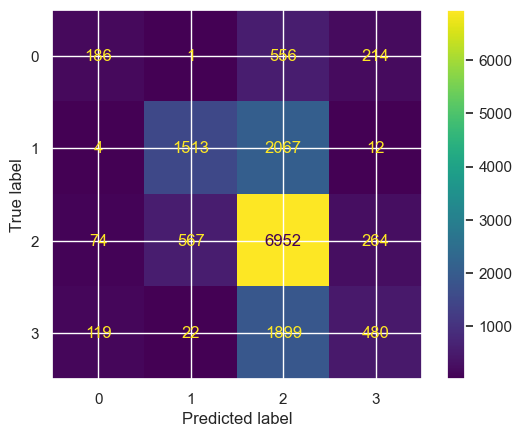

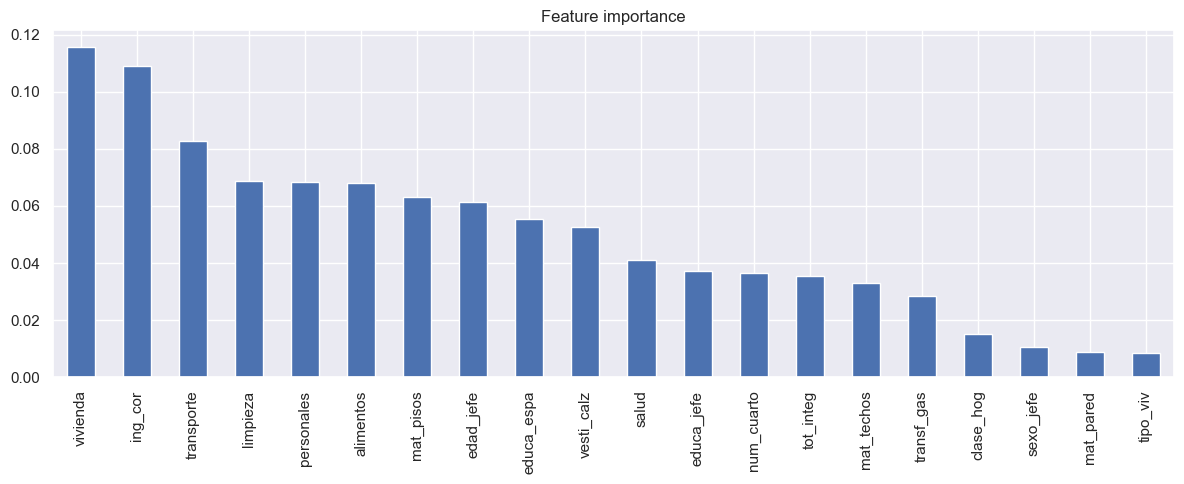

In [48]:
# Encoding
variables_categoricas = ["clase_hog", "sexo_jefe", "educa_jefe", "tipo_viv", "mat_pared", "mat_techos", "mat_pisos"]
for i in variables_categoricas:
    label_encoder(i)

le = LabelEncoder()
y = le.fit_transform(enigh["est_socio"])

# Variables predictoras
x = enigh[["clase_hog", "sexo_jefe", "edad_jefe", "tot_integ", "ing_cor", 
          "alimentos", "salud", "educa_espa", "educa_jefe", "vivienda", 
          "limpieza", "transporte", "personales", "transf_gas", "vesti_calz",
          "tipo_viv", "mat_pared", "mat_techos", "mat_pisos", "num_cuarto"]]



x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
# Model
rf = RandomForestClassifier(n_estimators=400, random_state=42,class_weight='balanced')
rf.fit(x_train, y_train)
# Evaluación
y_pred = rf.predict(x_test)
print(classification_report(y_test, y_pred))
# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()
# Importancia de variables
importancias = pd.Series(rf.feature_importances_, index=x.columns)
importancias.sort_values(ascending=False).plot(kind='bar', figsize=(12, 5))
plt.title('Feature importance')
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.43      0.24      0.31       957
           1       0.67      0.49      0.57      3596
           2       0.63      0.81      0.71      7857
           3       0.46      0.31      0.37      2520

    accuracy                           0.61     14930
   macro avg       0.55      0.46      0.49     14930
weighted avg       0.60      0.61      0.59     14930



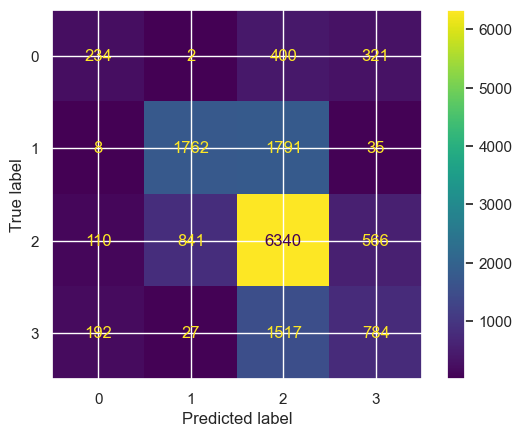

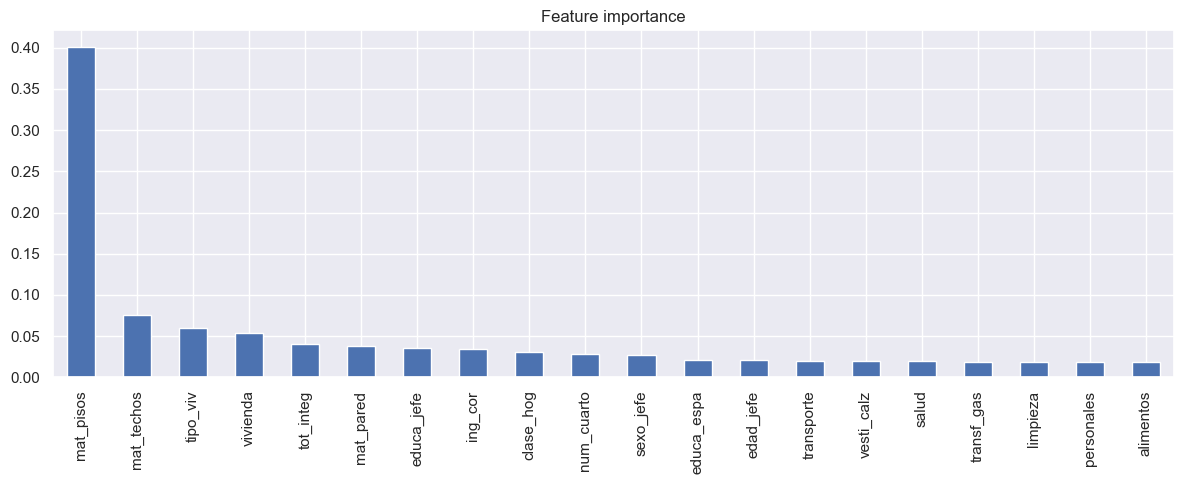

In [43]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=300, random_state=42, eval_metric='mlogloss')
xgb.fit(x_train, y_train)
y_pred = xgb.predict(x_test)
print(classification_report(y_test, y_pred))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# Importancia de variables
importancias = pd.Series(xgb.feature_importances_, index=x.columns)
importancias.sort_values(ascending=False).plot(kind='bar', figsize=(12, 5))
plt.title('Feature importance')
plt.tight_layout()
plt.show()

Random Forest provided a more balanced and interpretable feature importance analysis, while XGBoost concentrated importance on a single variable, making Random Forest more suitable for socioeconomic analysis in this context

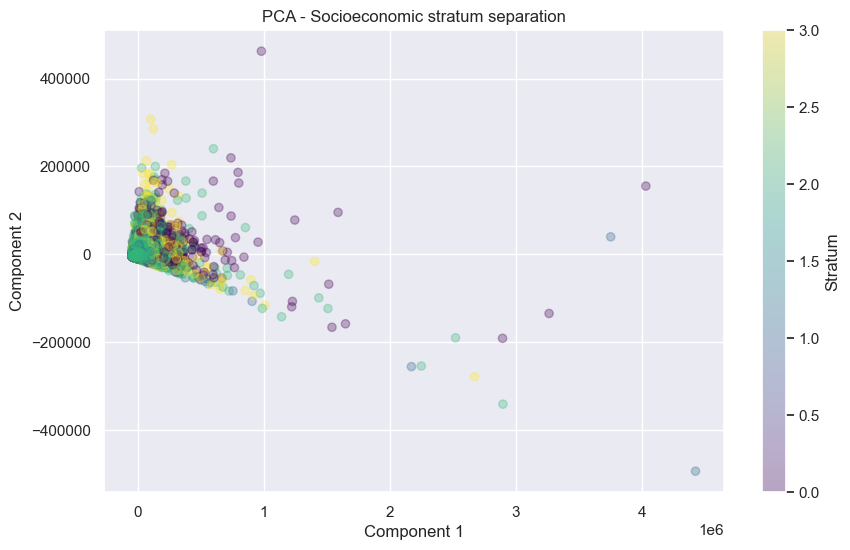

In [45]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(x_pca[:, 0], x_pca[:, 1], c=y, cmap='viridis', alpha=0.3)
plt.colorbar(scatter, label='Stratum')
plt.title('PCA - Socioeconomic stratum separation')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

A PCA projection of the data revealed significant overlap between socioeconomic strata, visually confirming the inherent difficulty of the classification task with the available variables. This overlap suggests that the selected features do not fully capture the boundaries between strata, which is consistent with the model's 61% accuracy."

# Conclusions

This study applied a Random Forest classifier to predict the socioeconomic stratum of Mexican households using data from the 2018 ENIGH survey. The model achieved an accuracy of 61%, which, while moderate, reflects the inherent complexity of the classification task rather than a limitation of the methodology.
The exploratory data analysis revealed that income and expenditure variables, particularly current income and transportation expenditure, are stronger predictors of socioeconomic stratum than physical housing characteristics such as construction materials. This suggests that household economic behavior is more indicative of socioeconomic status than the physical conditions of the dwelling.
A PCA projection confirmed significant overlap between strata in the available variable space, visually explaining the model's accuracy ceiling. Furthermore, the classification report showed that middle strata were predicted more accurately than extreme strata, indicating that households at the lower and upper ends of the socioeconomic scale are harder to classify with the available variables.
Compared to XGBoost, Random Forest provided a more balanced and interpretable feature importance analysis, making it more suitable for socioeconomic research. XGBoost concentrated predictive importance on a single variable, while Random Forest distributed importance across multiple variables, offering a richer understanding of the factors that define socioeconomic stratum.
Future work could improve model performance by incorporating additional variables such as access to public services, geographic location, and asset ownership, which may better capture the multidimensional nature of socioeconomic stratification in Mexico.
